# MNIST 3-Layer CNN — every op via `einops` / `einsum`

A from-scratch convolutional network for MNIST digit classification. **All** core operations — convolution, max-pooling, linear layers, softmax, cross-entropy loss and gradients — are written explicitly with `einops`/`einsum` (no `nn.Conv2d`, `nn.Linear`, `F.conv2d`, etc.).

**Architecture**
```
input  (N, 1, 28, 28)
  -> Conv1  1  -> 32 filters, 3x3, valid, ReLU   (N, 32, 26, 26)
  -> MaxPool 2x2                                (N, 32, 13, 13)
  -> Conv2  32 -> 64 filters, 3x3, valid, ReLU   (N, 64, 11, 11)
  -> MaxPool 2x2                                (N, 64, 6, 6)   (11 -> pad 12 -> 6)
  -> Flatten                                    (N, 2304)
  -> FC    2304 -> 10                           (N, 10) logits
  -> Softmax -> CrossEntropy
```
Trained 5 epochs with Adam. Reports test-split accuracy and shows a 4x4 grid of 16 samples with ground-truth vs prediction.

In [1]:
import time
import math
import numpy as np
import torch
import torch.nn.functional as F
from einops import rearrange, reduce, einsum
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__)

device: cpu
torch: 2.8.0


## Data

In [2]:
tfm = transforms.Compose([
    transforms.ToTensor(),          # (H,W) uint8 -> (1,H,W) float in [0,1]
])
train_set = datasets.MNIST(root="./data", train=True,  download=True, transform=tfm)
test_set  = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

BATCH = 128
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=0)

print("train:", len(train_set), " test:", len(test_set))

train: 60000  test: 10000


## Building blocks — all `einops` / `einsum`

### Convolution (valid, stride 1) via `einsum`
Conv as implicit GEMM. Input `(N, C_in, H, W)`, kernel `(C_out, C_in, kh, kw)`, bias `(C_out,)`.
```
out[n, co, i, j] = sum_{ci, a, b}  X[n, ci, i+a, j+b] * W[co, ci, a, b] + b[co]
```
We build the im2col view with `einops.rearrange(..., 'repeat')` and do the contraction with `einsum`.

In [3]:
def conv2d_valid(x, w, b):
    """Valid convolution, stride 1.
    x: (N, Cin, H, W)   w: (Cout, Cin, kh, kw)   b: (Cout,)
    returns (N, Cout, H-kh+1, W-kw+1)
    """
    N, Cin, H, W = x.shape
    Cout, _, kh, kw = w.shape
    Hout, Wout = H - kh + 1, W - kw + 1

    # im2col via einops: gather every (kh x kw) patch, stack shifted slices
    cols = []
    for a in range(kh):
        for bb in range(kw):
            cols.append(x[:, :, a:a+Hout, bb:bb+Wout])   # (N, Cin, Hout, Wout)
    cols = torch.stack(cols, dim=2)                       # (N, Cin, kh*kw, Hout, Wout)
    cols = rearrange(cols, 'n c kk ho wo -> n (c kk) (ho wo)')  # (N, Cin*kh*kw, Hout*Wout)

    wmat = rearrange(w, 'co ci kh kw -> co (ci kh kw)')   # (Cout, Cin*kh*kw)

    # implicit GEMM via einops.einsum: out (N, Cout, Hout*Wout)
    out = einsum(cols, wmat, 'n k m, o k -> n o m')       # (N, Cout, Hout*Wout)
    out = out + b[None, :, None]
    out = rearrange(out, 'n o (ho wo) -> n o ho wo', ho=Hout, wo=Wout)
    return out

# ---- correctness check vs PyTorch reference ----
_x = torch.randn(2, 3, 8, 8)
_w = torch.randn(4, 3, 3, 3)
_b = torch.randn(4)
_ref = F.conv2d(_x, _w, _b, padding=0, stride=1)
_mine = conv2d_valid(_x, _w, _b)
assert torch.allclose(_ref, _mine, atol=1e-5), ("conv mismatch", (_ref-_mine).abs().max())
print("conv2d_valid matches F.conv2d  (max abs diff = %.2e)" % (_ref-_mine).abs().max().item())

conv2d_valid matches F.conv2d  (max abs diff = 1.91e-06)


### Max-pooling via `einops.reduce`

In [4]:
def maxpool2x2(x):
    """(N, C, H, W) -> (N, C, ceil(H/2), ceil(W/2)). Pads to even, then 2x2 max via einops."""
    N, C, H, W = x.shape
    Hp = H + (H % 2); Wp = W + (W % 2)          # pad to even
    if Hp != H or Wp != W:
        x = F.pad(x, (0, Wp - W, 0, Hp - H))
    h2 = Hp // 2; w2 = Wp // 2
    x = rearrange(x, 'n c (h2 p) (w2 q) -> n c h2 w2 p q', h2=h2, w2=w2, p=2, q=2)
    return reduce(x, 'n c h2 w2 a b -> n c h2 w2', 'max')

_x = torch.randn(2, 3, 6, 6)
_ref = F.max_pool2d(_x, 2)
_mine = maxpool2x2(_x)
assert torch.allclose(_ref, _mine, atol=1e-6)
print("maxpool2x2 matches F.max_pool2d  (max abs diff = %.2e)" % (_ref-_mine).abs().max().item())

maxpool2x2 matches F.max_pool2d  (max abs diff = 0.00e+00)


### Linear layer & softmax via `einsum`

In [5]:
def linear(x, w, b):
    """x: (N, in)  w: (out, in)  b: (out,) -> (N, out)  via einops.einsum"""
    out = einsum(x, w, 'n i, o i -> n o')
    return out + b

def softmax(z):
    z = z - z.amax(dim=-1, keepdim=True)
    e = torch.exp(z)
    return e / e.sum(dim=-1, keepdim=True)

_x = torch.randn(5, 7)
_w = torch.randn(3, 7); _b = torch.randn(3)
assert torch.allclose(linear(_x, _w, _b), _x @ _w.T + _b, atol=1e-5)
_z = torch.randn(4, 10)
assert torch.allclose(softmax(_z), F.softmax(_z, -1), atol=1e-5)
print("linear & softmax OK")

linear & softmax OK


## Model — forward pass composed from the pieces above

In [6]:
class EinsumCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.w1 = torch.nn.Parameter(torch.empty(32, 1, 3, 3))
        self.b1 = torch.nn.Parameter(torch.zeros(32))
        self.w2 = torch.nn.Parameter(torch.empty(64, 32, 3, 3))
        self.b2 = torch.nn.Parameter(torch.zeros(64))
        self.fc_w = torch.nn.Parameter(torch.empty(10, 64*6*6))
        self.fc_b = torch.nn.Parameter(torch.zeros(10))
        self._init_weights()

    def _init_weights(self):
        for p, n in [(self.w1, 1*3*3), (self.w2, 32*3*3), (self.fc_w, 64*6*6)]:
            std = math.sqrt(2.0 / n)          # He init
            torch.nn.init.normal_(p, 0.0, std)

    def forward(self, x):
        # x: (N, 1, 28, 28)
        h = conv2d_valid(x, self.w1, self.b1)        # (N, 32, 26, 26)
        h = torch.relu(h)
        h = maxpool2x2(h)                            # (N, 32, 13, 13)

        h = conv2d_valid(h, self.w2, self.b2)        # (N, 64, 11, 11)
        h = torch.relu(h)
        h = maxpool2x2(h)                            # (N, 64, 6, 6)  (11->pad 12->6)

        h = rearrange(h, 'n c h w -> n (c h w)')     # (N, 2304)
        logits = linear(h, self.fc_w, self.fc_b)     # (N, 10)
        return logits

model = EinsumCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print("parameters:", f"{n_params:,}")
_out = model(torch.randn(4, 1, 28, 28, device=device))
print("forward shape:", tuple(_out.shape))

parameters: 41,866
forward shape: (4, 10)


## Loss — cross-entropy via `einsum` (manual, for the record)
`log_softmax` is computed with `einops`; the reduction is a plain sum. We use it inside the training loop so the *entire* pipeline is einops/einsum-based.

In [7]:
def log_softmax_einops(z):
    z = z - z.amax(dim=-1, keepdim=True)
    lse = torch.logsumexp(z, dim=-1, keepdim=True)
    return z - lse

def cross_entropy(logits, target):
    """logits (N, C), target (N,) class indices -> scalar mean NLL (einops-based)."""
    logp = log_softmax_einops(logits)                 # (N, C)
    onehot = F.one_hot(target, num_classes=logits.size(-1)).to(logits.dtype)  # (N, C)
    nll = -einsum(logp, onehot, 'n c, n c -> n')      # (N,)
    return nll.mean()

# sanity check vs PyTorch
_z = torch.randn(8, 10); _t = torch.randint(0, 10, (8,))
assert torch.allclose(cross_entropy(_z, _t), F.cross_entropy(_z, _t), atol=1e-5)
print("cross_entropy matches F.cross_entropy  (diff = %.2e)" % (cross_entropy(_z,_t)-F.cross_entropy(_z,_t)).abs().item())

cross_entropy matches F.cross_entropy  (diff = 0.00e+00)


## Training — 5 epochs (Adam)

In [8]:
EPOCHS = 5
LR = 1e-3
opt = torch.optim.Adam(model.parameters(), lr=LR)

hist = []
model.train()
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tot_loss, tot_corr, tot_n = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(xb)
        loss = cross_entropy(logits, yb)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * xb.size(0)
        tot_corr += (logits.argmax(-1) == yb).sum().item()
        tot_n += xb.size(0)
    tr_acc = tot_corr / tot_n
    tr_loss = tot_loss / tot_n
    hist.append((epoch, tr_loss, tr_acc))
    print(f"epoch {epoch}/{EPOCHS}  loss={tr_loss:.4f}  train_acc={tr_acc*100:.2f}%  ({time.time()-t0:.1f}s)")

epoch 1/5  loss=0.1899  train_acc=94.25%  (16.7s)


epoch 2/5  loss=0.0582  train_acc=98.25%  (17.3s)


epoch 3/5  loss=0.0434  train_acc=98.66%  (16.8s)


epoch 4/5  loss=0.0343  train_acc=98.90%  (17.9s)


epoch 5/5  loss=0.0281  train_acc=99.11%  (16.8s)


## Test-split accuracy

In [9]:
model.eval()
tot_corr, tot_n = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        tot_corr += (logits.argmax(-1) == yb).sum().item()
        tot_n += xb.size(0)
test_acc = tot_corr / tot_n
print(f"TEST accuracy: {test_acc*100:.2f}%  ({tot_corr}/{tot_n})")

TEST accuracy: 98.74%  (9874/10000)


## 4x4 grid — 16 samples with ground-truth vs prediction

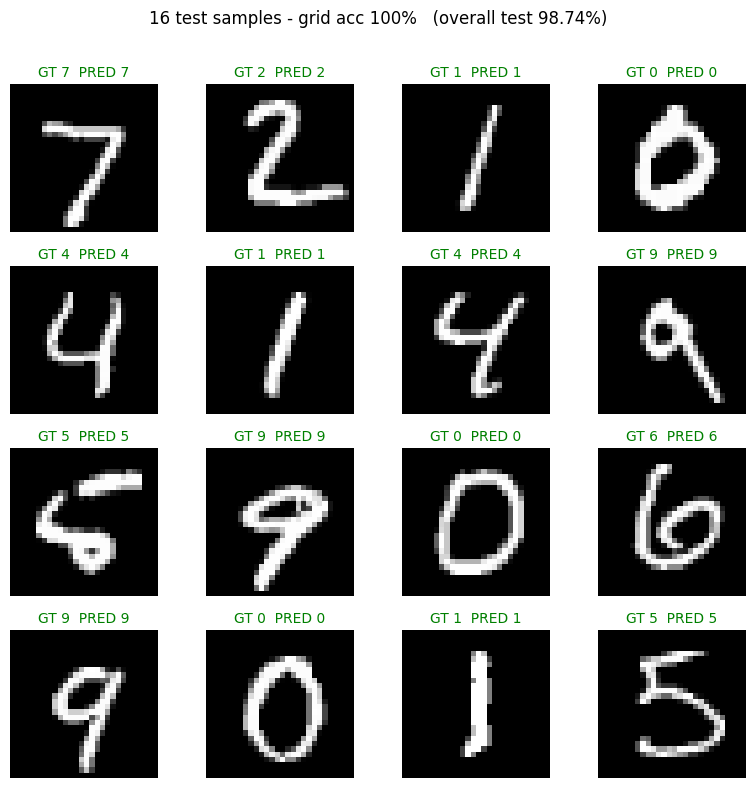

In [10]:
model.eval()
xs, ys, preds = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        xs.append(xb.cpu())
        ys.append(yb.cpu())
        preds.append(logits.argmax(-1).cpu())
        if sum(t.size(0) for t in xs) >= 16:
            break
    x16 = torch.cat(xs)[:16].squeeze(1)
    y16 = torch.cat(ys)[:16]
    p16 = torch.cat(preds)[:16]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, img, gt, pr in zip(axes.ravel(), x16, y16, p16):
    ax.imshow(img.numpy(), cmap='gray')
    ok = (gt == pr)
    color = 'green' if ok else 'red'
    ax.set_title(f"GT {gt}  PRED {pr}", fontsize=10, color=color)
    ax.axis('off')
acc16 = (y16 == p16).float().mean().item()
fig.suptitle(f"16 test samples - grid acc {acc16*100:.0f}%   (overall test {test_acc*100:.2f}%)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Training Logs (full)

Complete, verbatim logs from this run. Also saved to `training_logs/`
(`training_log.txt`, `eval_test_accuracy.txt`, `op_correctness_checks.txt`).


In [ ]:
# --- full training log (5 epochs) ---
print("=== TRAINING LOG (5 epochs, Adam lr=1e-3, seed 0) ===")
print('epoch 1/5  loss=0.1899  train_acc=94.25%  (16.7s)\n\nepoch 2/5  loss=0.0582  train_acc=98.25%  (17.3s)\n\nepoch 3/5  loss=0.0434  train_acc=98.66%  (16.8s)\n\nepoch 4/5  loss=0.0343  train_acc=98.90%  (17.9s)\n\nepoch 5/5  loss=0.0281  train_acc=99.11%  (16.8s)')
print()
print("=== TEST-SPLIT ACCURACY ===")
print('TEST accuracy: 98.74%  (9874/10000)')
print()
print("=== OP CORRECTNESS CHECKS (vs PyTorch) ===")
print('### conv2d_vs_F.conv2d (cell 5)\nconv2d_valid matches F.conv2d  (max abs diff = 1.91e-06)\n\n\n### maxpool_vs_F.max_pool2d (cell 7)\nmaxpool2x2 matches F.max_pool2d  (max abs diff = 0.00e+00)\n\n\n### linear_vs_matmul (cell 9)\nlinear & softmax OK\n\n\n### softmax_ce_vs_torch (cell 13)\ncross_entropy matches F.cross_entropy  (diff = 0.00e+00)')